# Statistics for Michel electron candidate (28867 full run)

### Created by Shu, 20250604---

#### Focus here is PDS processing (Previous TPC processing [Space, MS, MH cuts] is at beamRun28867_FullRun)

#### Based on michelStat_20250602.ipynb

#### To explore the effect of narrower time window: [-0.10, 0.02]
#### In michelStat_20250602, the window is [-0.12, 0.03]


<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Test new peakFinder (Intensity info added!):

In [1]:
peakFinder_muTime = []
peakFinder_miTime = []
peakFinder_miCoin = []

#Reminder: decay points here are corresponding to events after all the filters---
decayX = []
decayY = []
decayZ = []


# Open the text file and process each line
with open('./statResult/peakFinder_muonTime_new20250604.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_muTime.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/peakFinder_michelTime_new20250604.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miTime.append(number)
            except ValueError:
                print(f"(michel time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/peakFinder_michelCoincidence_new20250604.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                peakFinder_miCoin.append(number)
            except ValueError:
                print(f"(michel coin) Could not convert {parts[1].strip()} to an integer.")


with open('./statResult/posX_extract.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/posY_extract.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/posZ_extract.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))




print("\nLength of peakFinder_muTime_new20250604:", len(peakFinder_muTime))
print("Length of peakFinder_miTime_new20250604:", len(peakFinder_miTime))
print("Length of peakFinder_miCoin_new20250604:", len(peakFinder_miCoin))

print("Length of decayX:", len(decayX))
print("Length of decayY:", len(decayY))
print("Length of decayZ:", len(decayZ))


Length of peakFinder_muTime_new20250604: 2751
Length of peakFinder_miTime_new20250604: 2751
Length of peakFinder_miCoin_new20250604: 2751
Length of decayX: 2751
Length of decayY: 2751
Length of decayZ: 2751


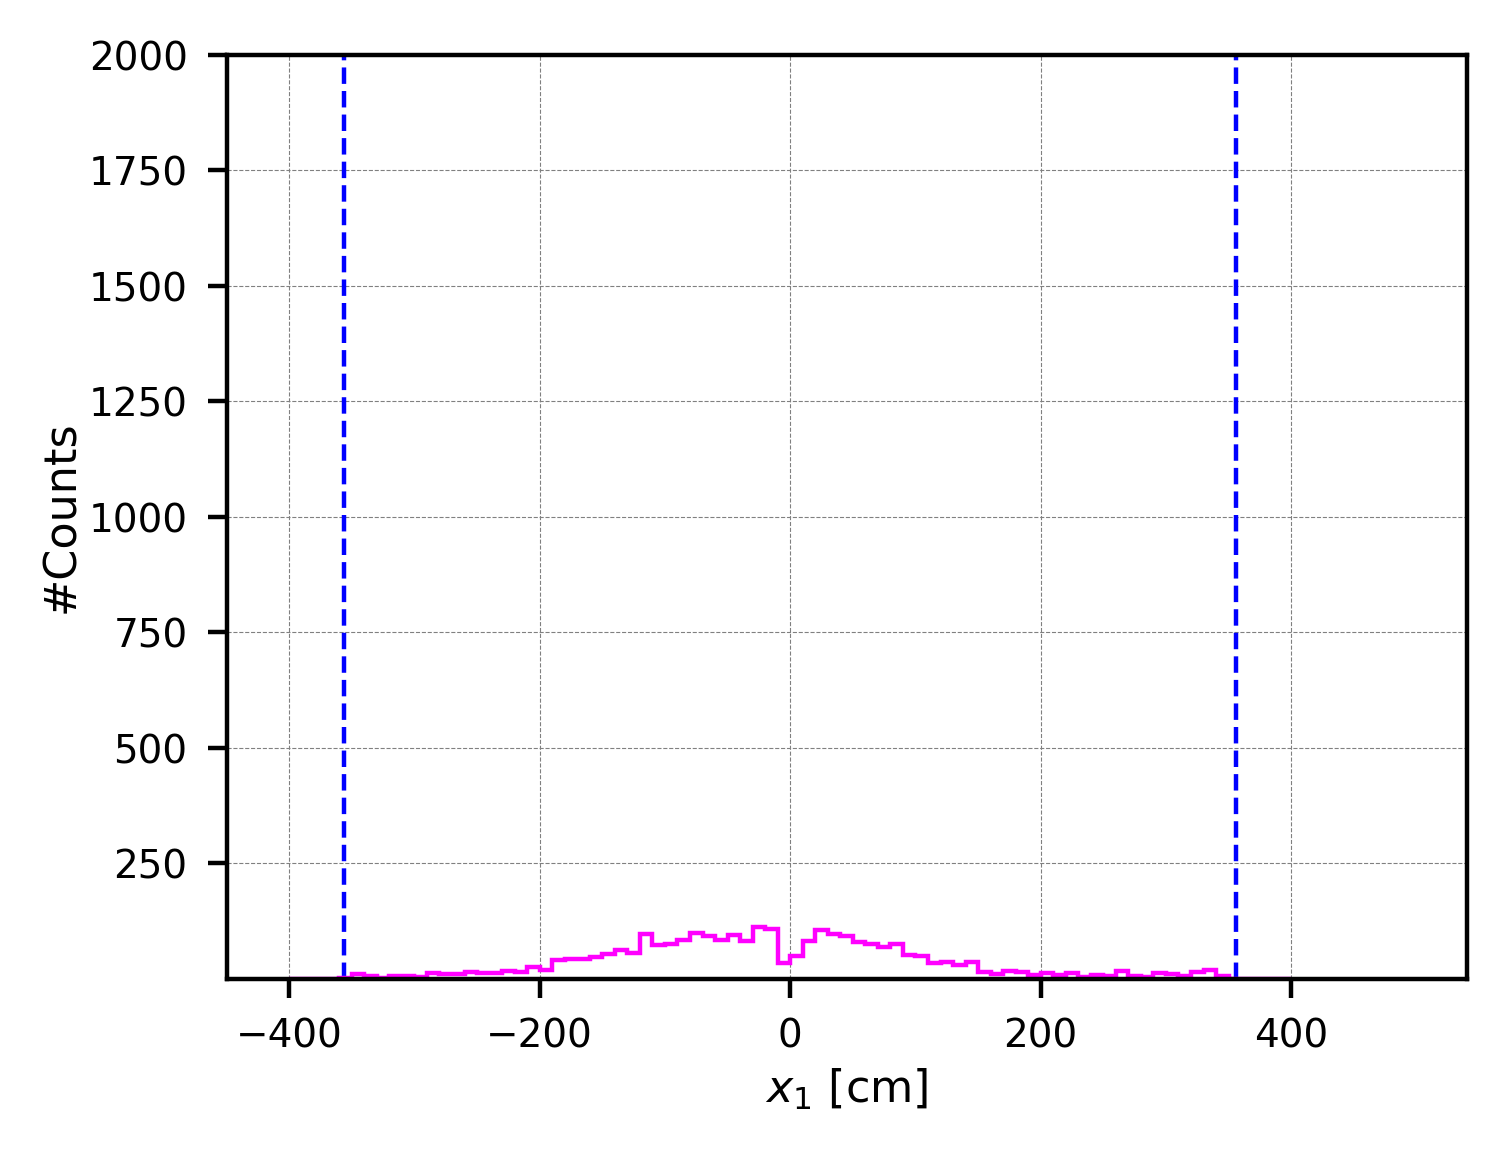

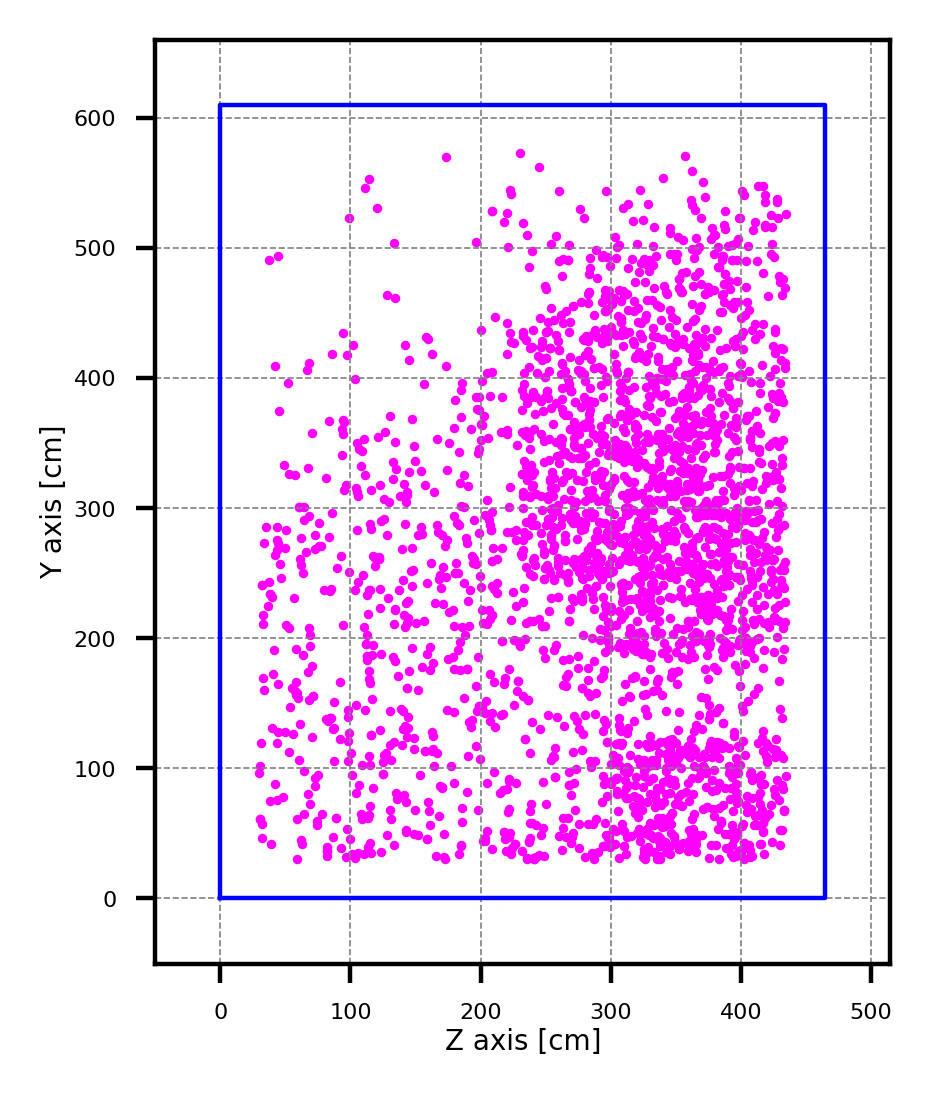

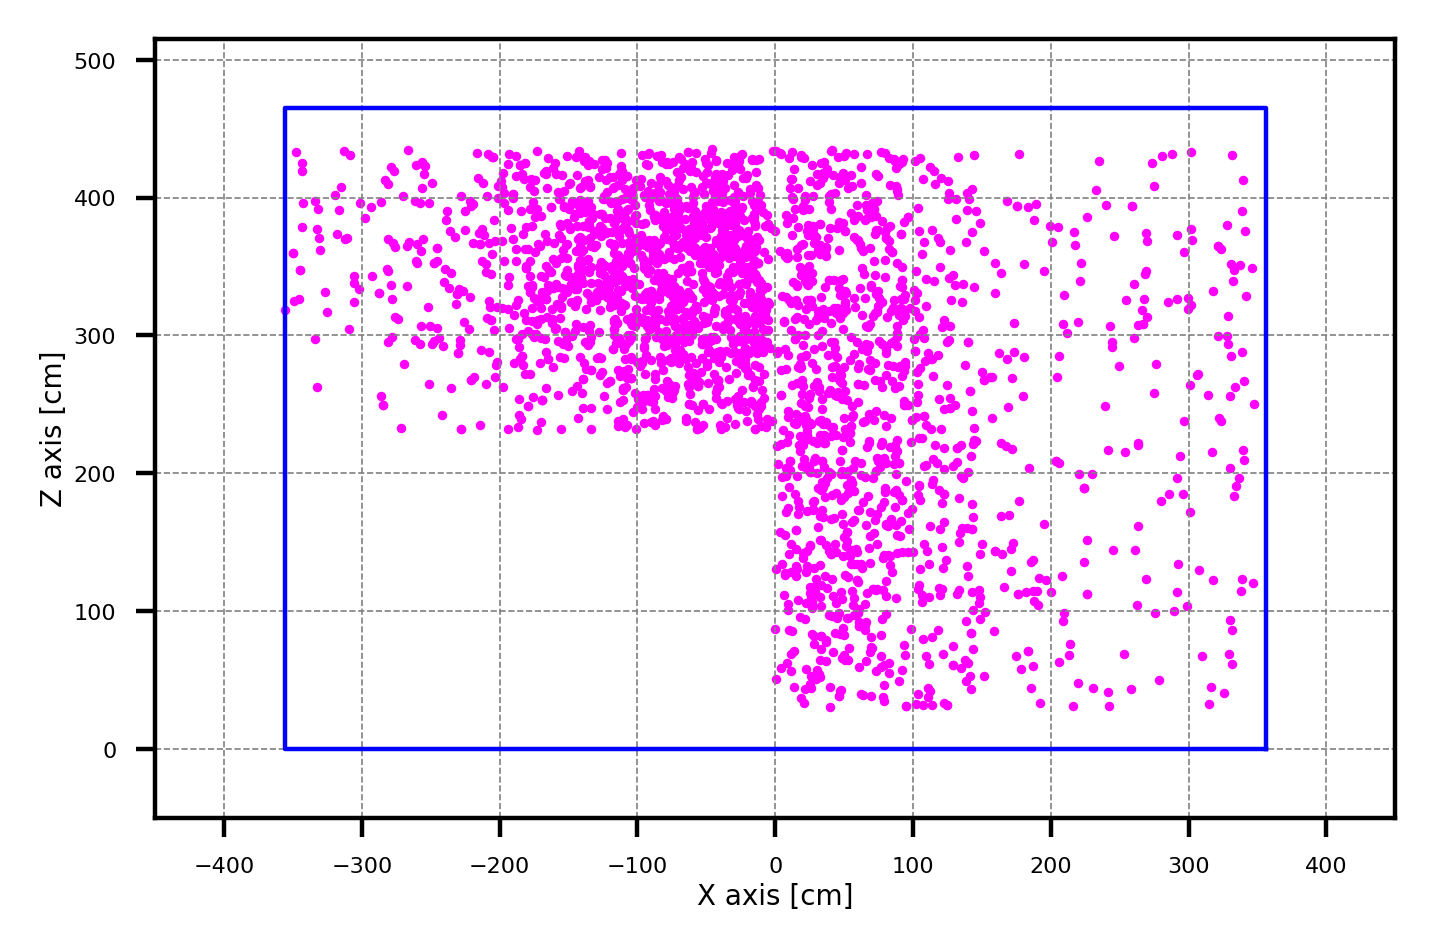

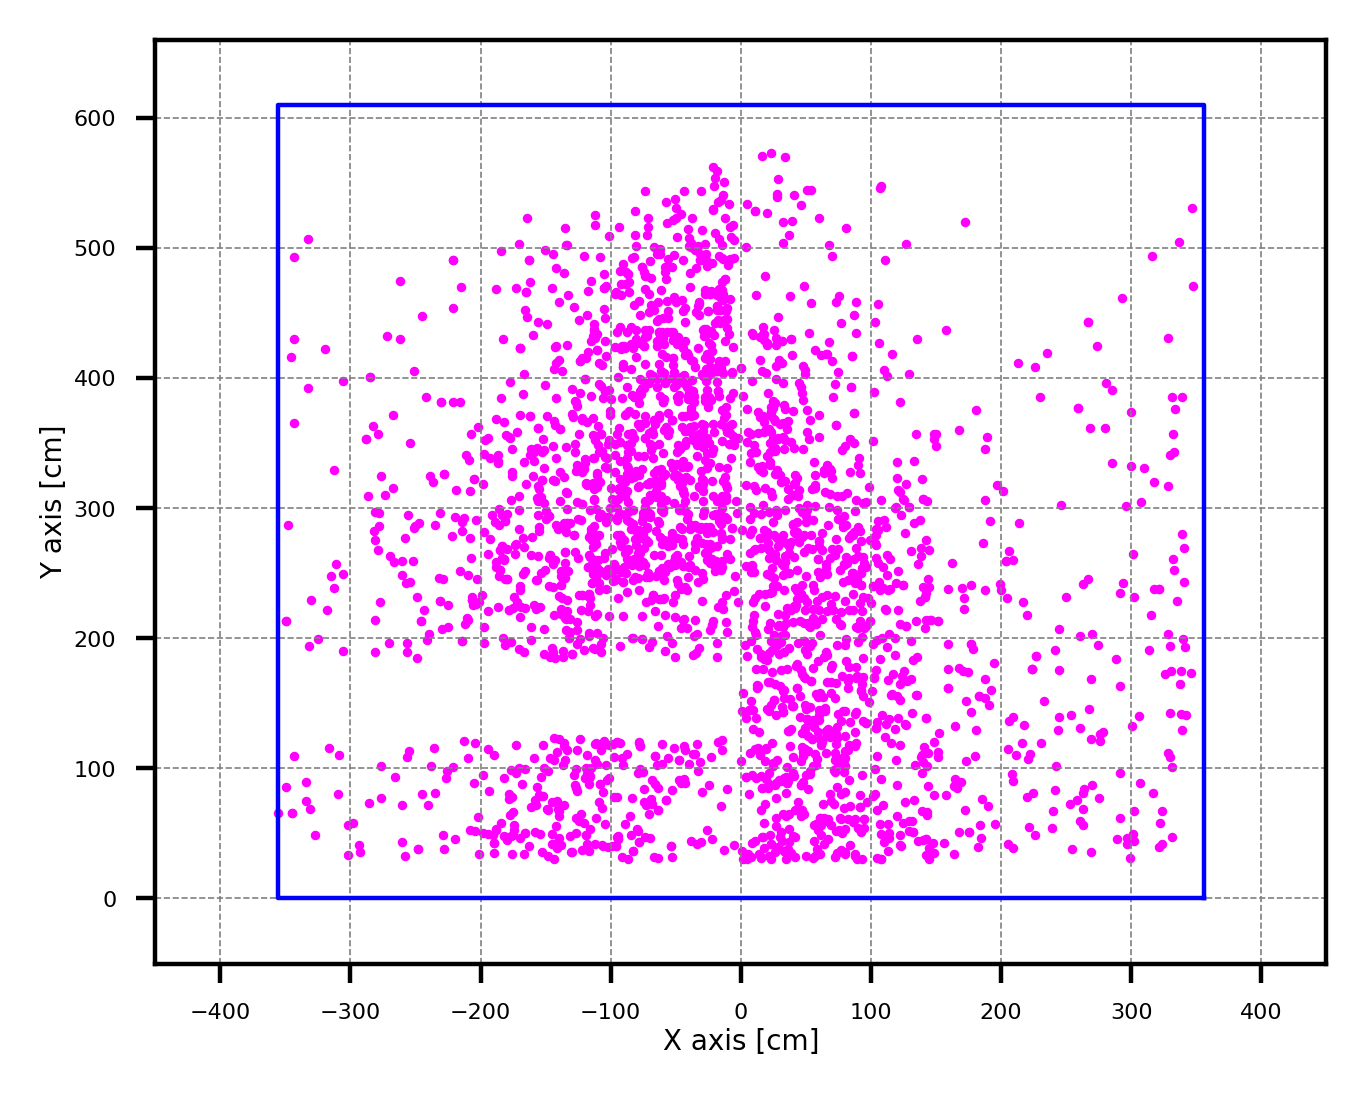

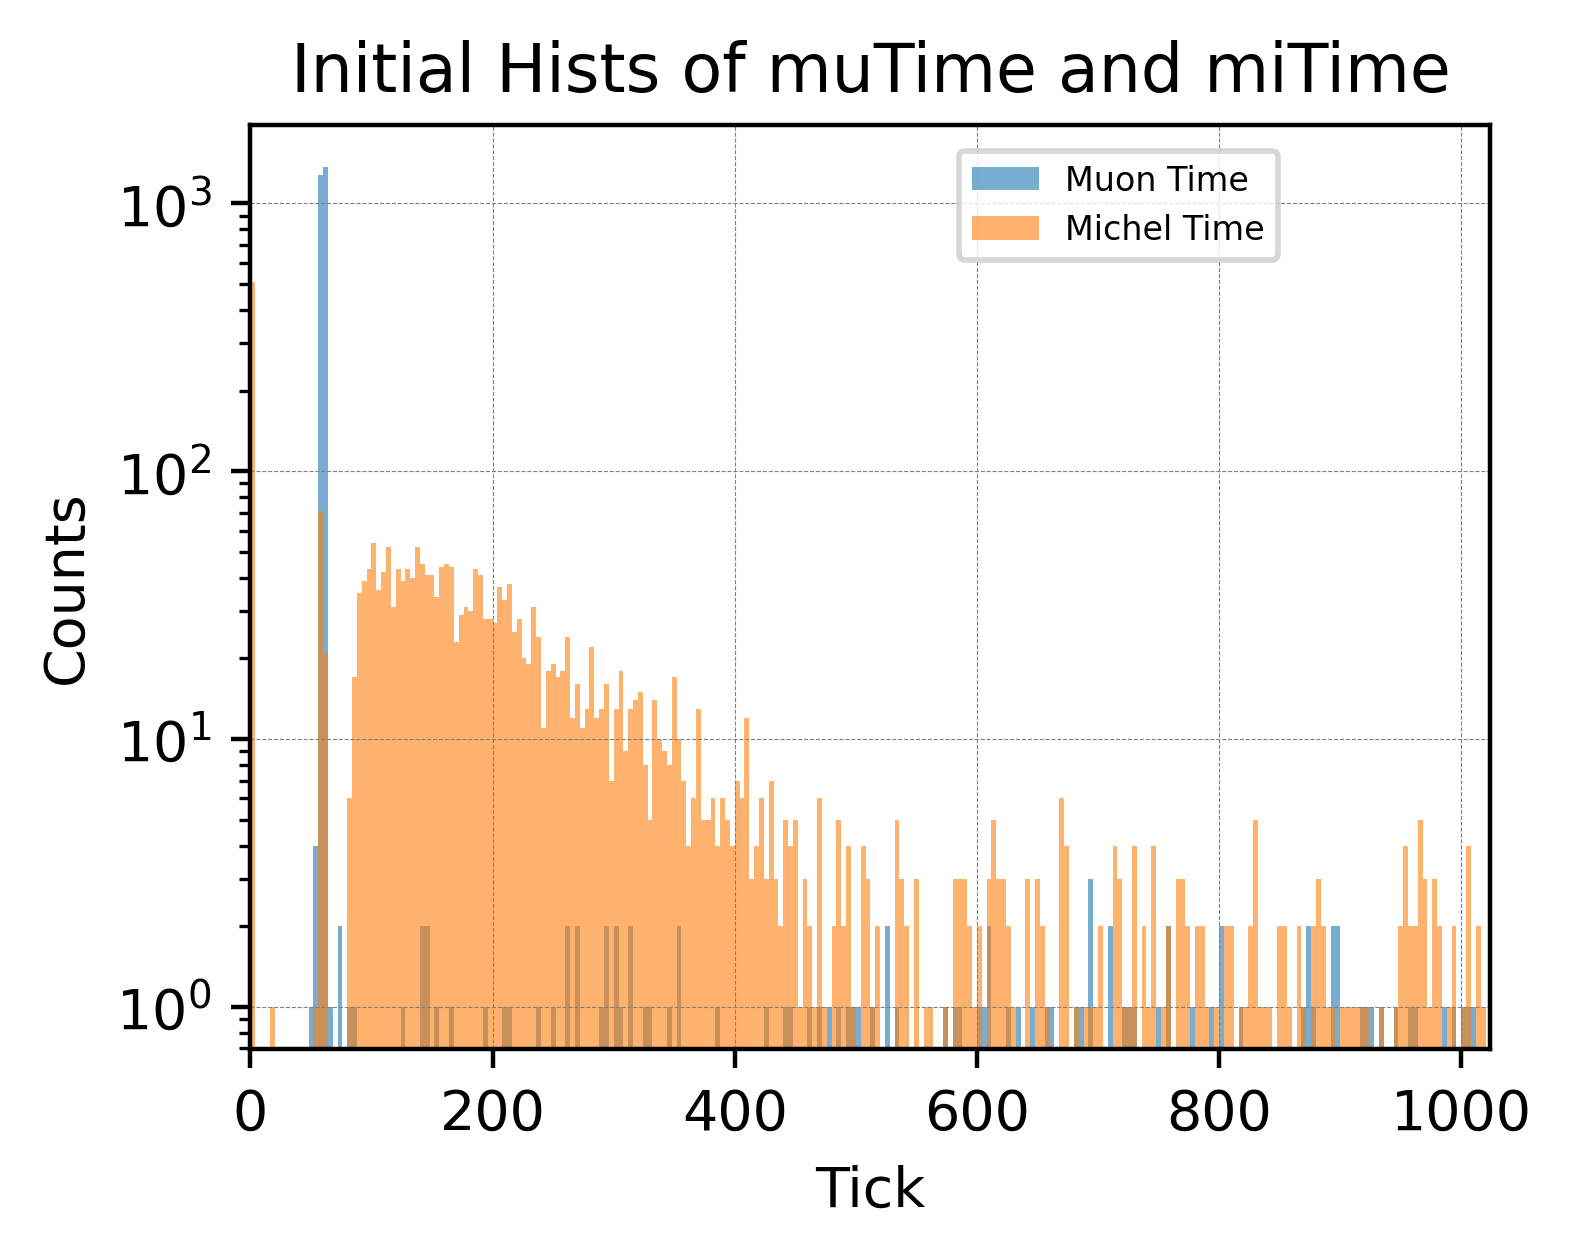

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465





# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-356, -356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)


plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 2000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()  







#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayZ, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  







#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX, decayZ, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


#Drawing of data points------
plt.scatter(decayX, decayY, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(peakFinder_muTime, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(peakFinder_miTime, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title('Initial Hists of muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()


<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals


Muon events purification (mu peak constrained to [55, 65]):

Purified Muon events:  2651 (96.36%)
Length of mu_lifetime (Updated):  2651
Length of updated coincidence  :  2651
Length of updated decayX       :  2651
Length of updated decayY       :  2651
Length of updated decayZ       :  2651


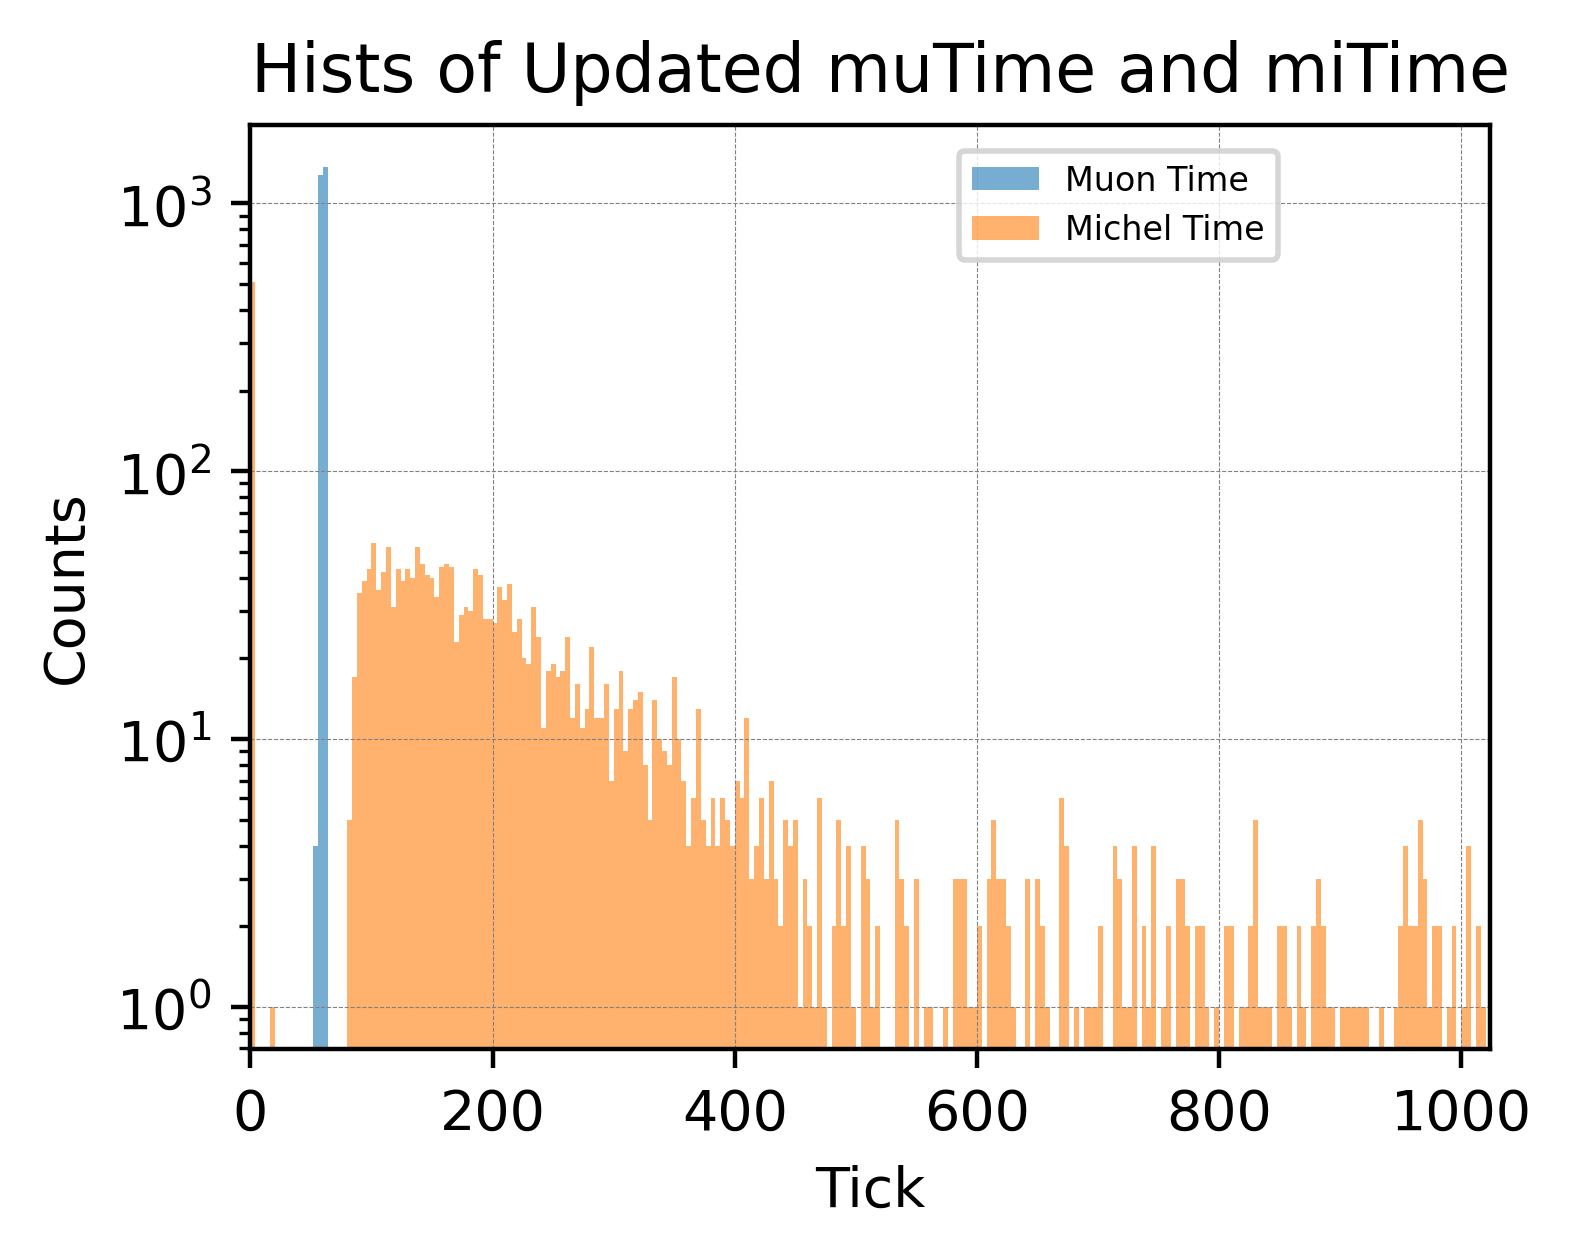




Lifetime distribution (Updated):
# Initial Candidates [-16000, 16000]:  2651
# Initial Candidates [0, 16000]:  2142 (80.80%)

Note: If there is no secondary peak (both heights >=0.5) found in summed wvf, the michel time will be recorded as 0 !


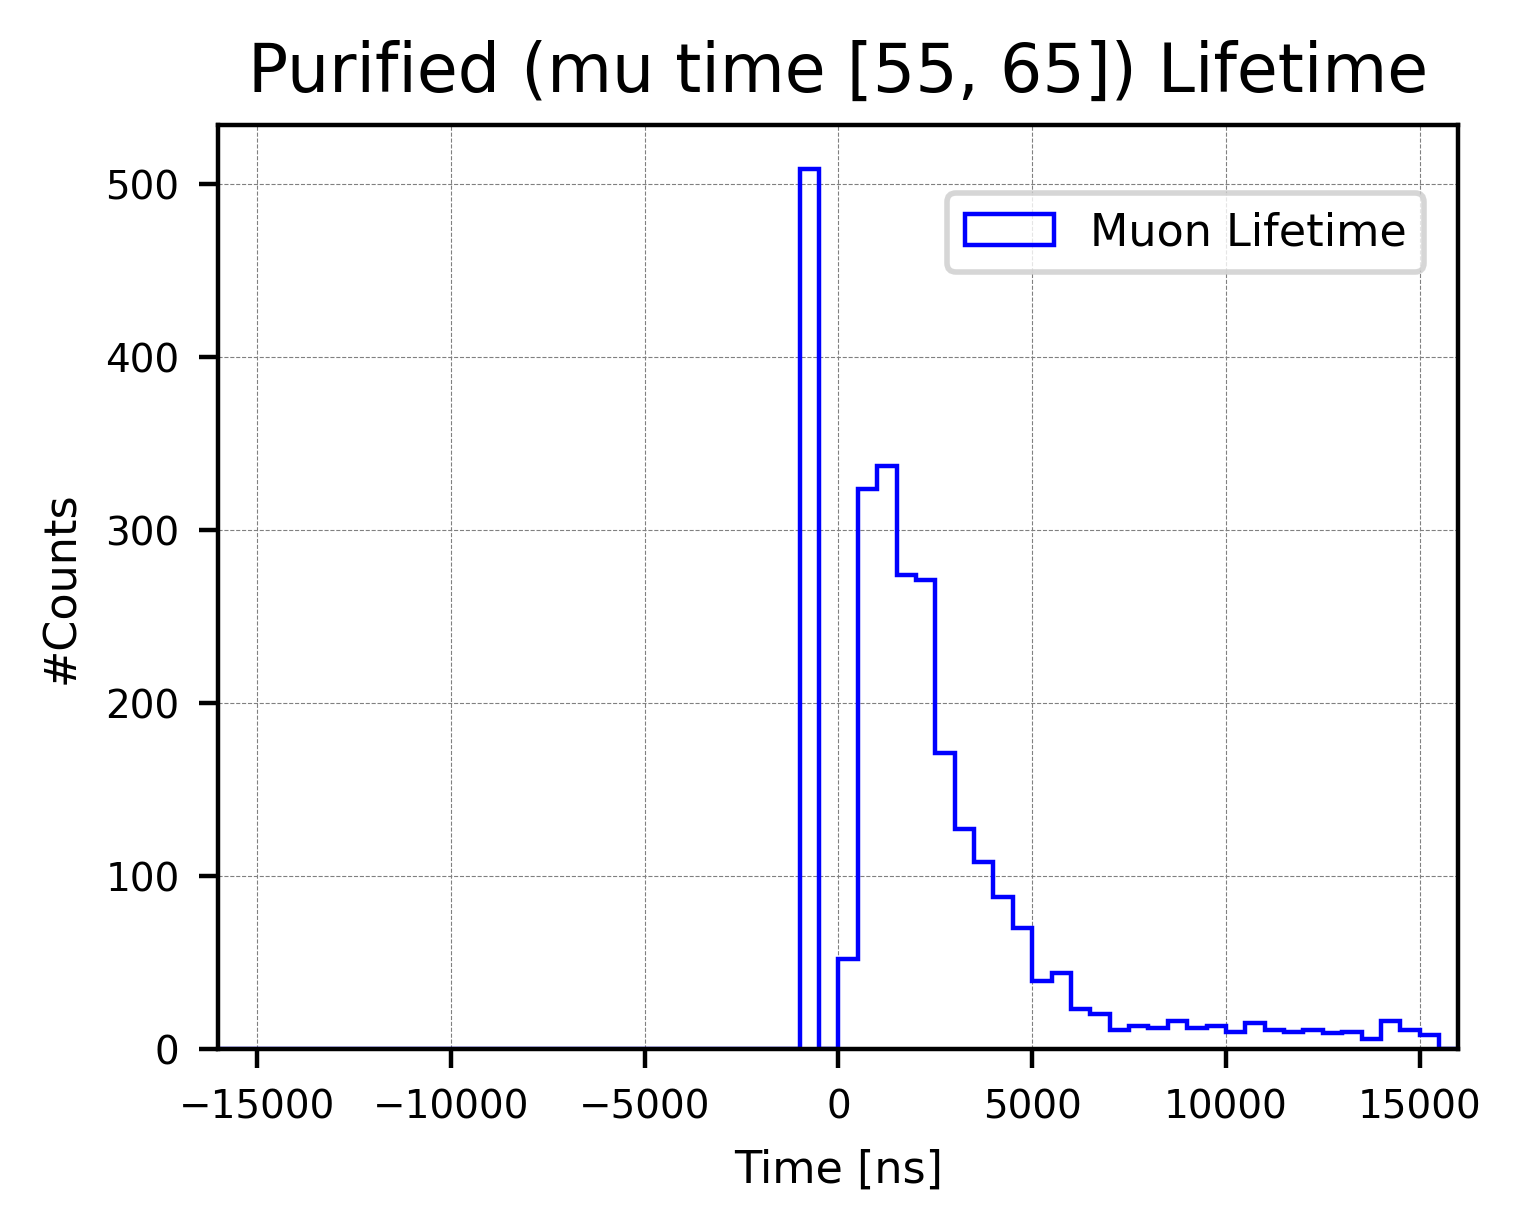

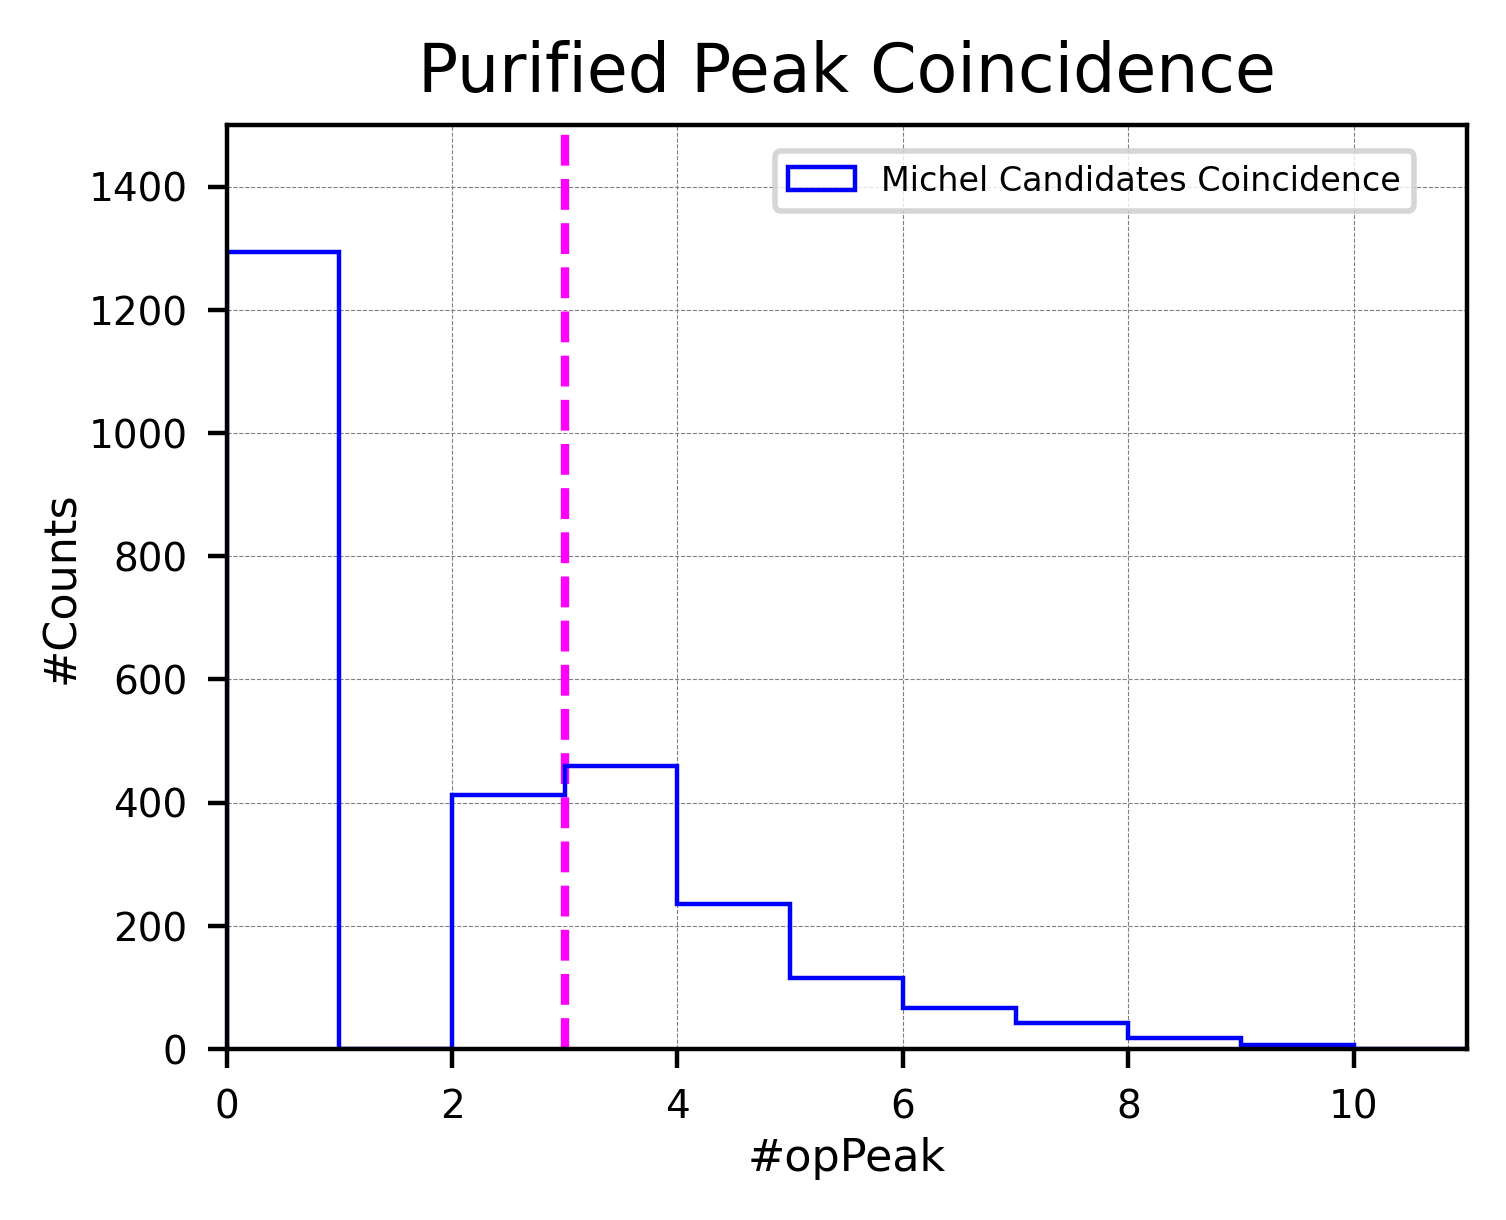

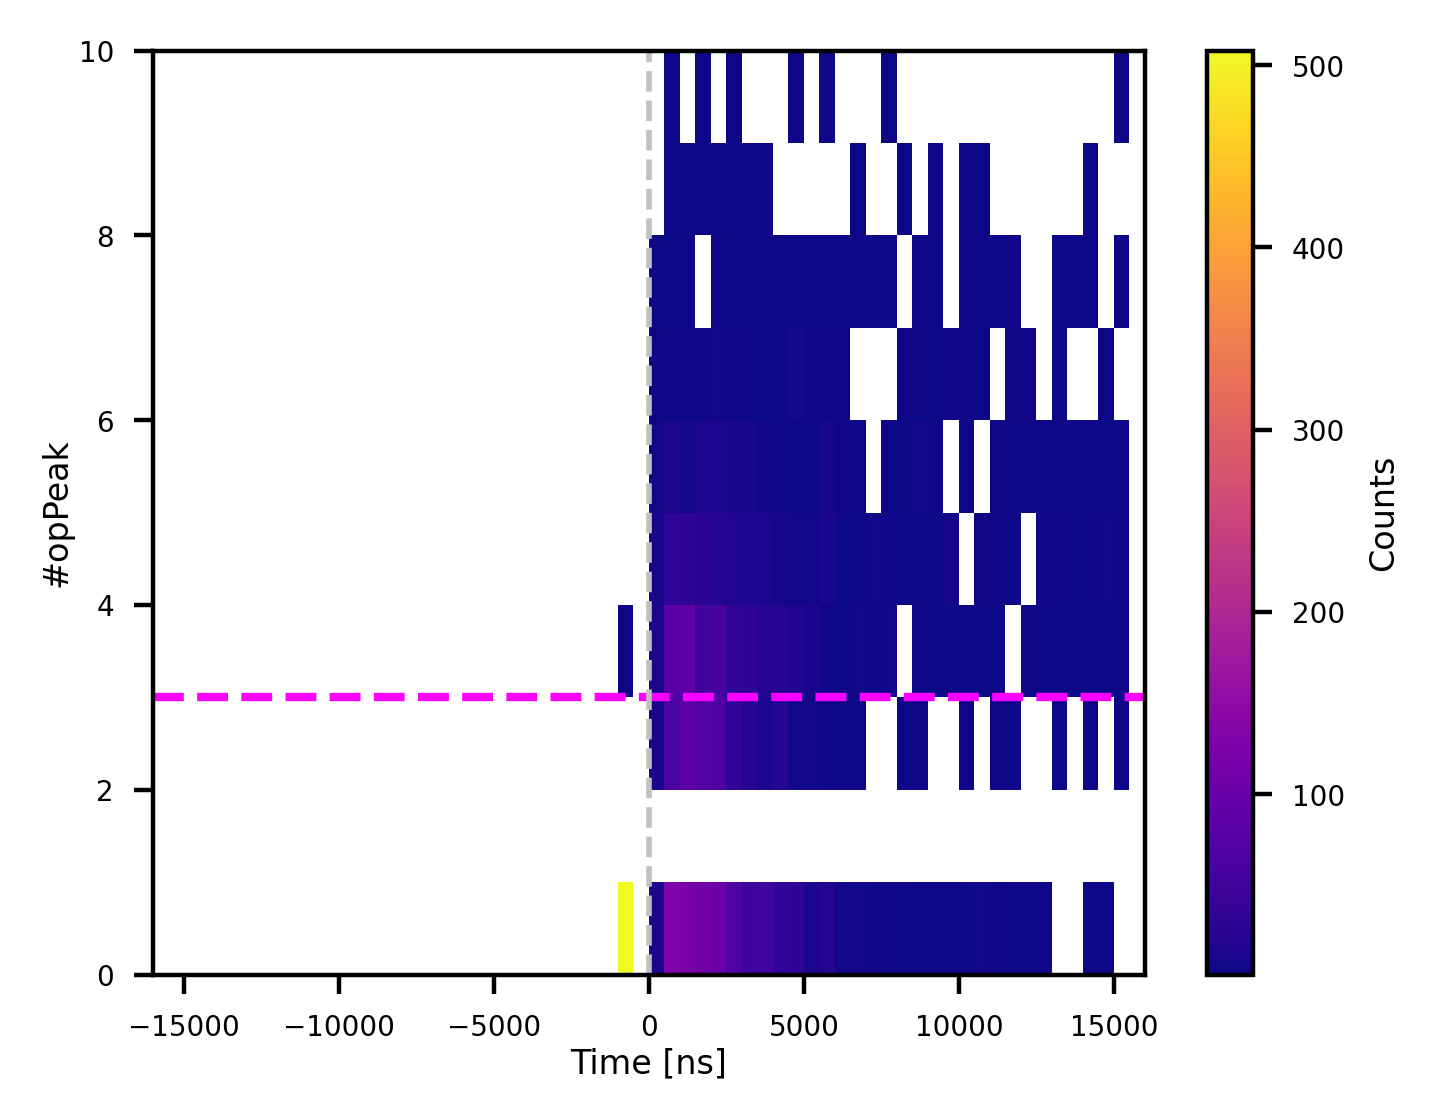

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


#Muon lifetime calculation-------------------------------------------------------------
# Only save muon time located in [55, 65]---
muTime_update = []
miTime_update = []
coin_update = [] #coincidence------
decayX_update = []
decayY_update = []
decayZ_update = []

for i in range(0, len(peakFinder_muTime)):
    mu = peakFinder_muTime[i]
    mi = peakFinder_miTime[i]
    miCoin = peakFinder_miCoin[i]
    x = decayX[i]
    y = decayY[i]
    z = decayZ[i]

    if 55 <= mu <= 65:
        muTime_update.append(mu)
        miTime_update.append(mi)
        coin_update.append(miCoin)
        decayX_update.append(x)
        decayY_update.append(y)
        decayZ_update.append(z)

print("\nMuon events purification (mu peak constrained to [55, 65]):")
print("\nPurified Muon events: ", len(muTime_update),
       "({:.2f}%)".format(len(muTime_update)/len(peakFinder_muTime)*100))

# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(miTime_update, muTime_update)]
print("Length of mu_lifetime (Updated): ", len(mu_lifetime))
print("Length of updated coincidence  : ", len(coin_update))
print("Length of updated decayX       : ", len(decayX_update))
print("Length of updated decayY       : ", len(decayY_update))
print("Length of updated decayZ       : ", len(decayY_update))









#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()










# Muon Lifetime distribution (INITIAL; NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Convert to ns (assuming mu_lifetime is already defined)
mu_lifetime_ns = [value * 16 for value in mu_lifetime]
print("\n\n\nLifetime distribution (Updated):")
print("# Initial Candidates [-16000, 16000]: ", len(mu_lifetime_ns))

# Apply test cut
mu_lifetime_ns_test = [val for val in mu_lifetime_ns if 0 < val < 16000]
print("# Initial Candidates [0, 16000]: ", len(mu_lifetime_ns_test), "({:.2f}%)".format(len(mu_lifetime_ns_test)/len(mu_lifetime_ns)*100))

print("\nNote: If there is no secondary peak (both heights >=0.5) found in summed wvf, the michel time will be recorded as 0 !")

# Define histogram parameters
bin_width = 500
range_min = -16000
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(-16000, 16000)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.title('Purified (mu time [55, 65]) Lifetime')
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()






# Michel coincidence distribution------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 1
range_min = 0
range_max = 11
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([3, 3], [0, 1500], color="magenta", linewidth=1.5, linestyle='--')

plt.hist(coin_update, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=0.8, label='Michel Candidates Coincidence')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

plt.xlim(0, 11)
plt.ylim(0, 1500)
plt.xlabel('#opPeak', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.title('Purified Peak Coincidence')
#plt.ylim(0.1, 1000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show() 






#Lifetime vs opWvf (Original)===============================================
plt.figure(figsize=(4,3),dpi=400)

#y=x---
plt.plot([-16000, 16000], [3, 3], color="magenta", linewidth=1.5, linestyle='--')
plt.plot([0, 0], [0, 10], color="silver", linewidth=1.0, linestyle='--')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(mu_lifetime_ns, coin_update, bins=(64, 10), range=[[-16000, 16000], [0, 10]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(-16000, 16000)
plt.ylim(0, 10)
plt.xlabel('Time [ns]', labelpad=1, fontsize=6)
plt.ylabel('#opPeak', labelpad=1, fontsize=6)

#plt.title('After Space Cut', fontsize=7)
plt.tick_params(labelsize=5)






<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />


### Purification 2: Lifetime & Coincidence Cuts

In [13]:
#After coincidence cut-----------------
mu_lifetime_ns_update_tmp = []
decayX_update_tmp = []
decayY_update_tmp = []
decayZ_update_tmp = []

#After coincidence and lifetime cut---
mu_lifetime_ns_update_2 = []
decayX_update_2 = []
decayY_update_2 = []
decayZ_update_2 = []



for i in range(0, len(coin_update)):
    coin = coin_update[i]
    time = mu_lifetime_ns[i] #mu_lifetime_ns is after "Purification 1"
    x = decayX_update[i]
    y = decayY_update[i]
    z = decayZ_update[i]

    if coin >= 3:
        mu_lifetime_ns_update_tmp.append(time)
        decayX_update_tmp.append(x)
        decayY_update_tmp.append(y)
        decayZ_update_tmp.append(z)

        if 500 <= time <= 16000:
            mu_lifetime_ns_update_2.append(time)
            decayX_update_2.append(x)
            decayY_update_2.append(y)
            decayZ_update_2.append(z)            



print("Keep #coincidence >=3:")    
print("# Purified (further) Candidates [-16000, 16000]: ", len(mu_lifetime_ns_update_tmp))

#Test-------
mu_lifetime_ns_purified_00 = [val for val in mu_lifetime_ns_update_tmp if 0 <= val <= 16000]
mu_lifetime_ns_purified_500 = [val for val in mu_lifetime_ns_update_tmp if 500 <= val <= 16000]
print("# Purified Candidates [0, 16000]: ", len(mu_lifetime_ns_purified_00))
print("# Purified Candidates [500, 16000]: ", len(mu_lifetime_ns_purified_500))

print("\nAfter peakCoin && Lifetiem cuts:")
print("mu_lifetime_ns_update_2: ", len(mu_lifetime_ns_update_2))
print("decayX_update_2        : ", len(decayX_update_2))
print("decayY_update_2        : ", len(decayY_update_2))
print("decayZ_update_2        : ", len(decayZ_update_2))






Keep #coincidence >=3:
# Purified (further) Candidates [-16000, 16000]:  944
# Purified Candidates [0, 16000]:  943
# Purified Candidates [500, 16000]:  914

After peakCoin && Lifetiem cuts:
mu_lifetime_ns_update_2:  914
decayX_update_2        :  914
decayY_update_2        :  914
decayZ_update_2        :  914


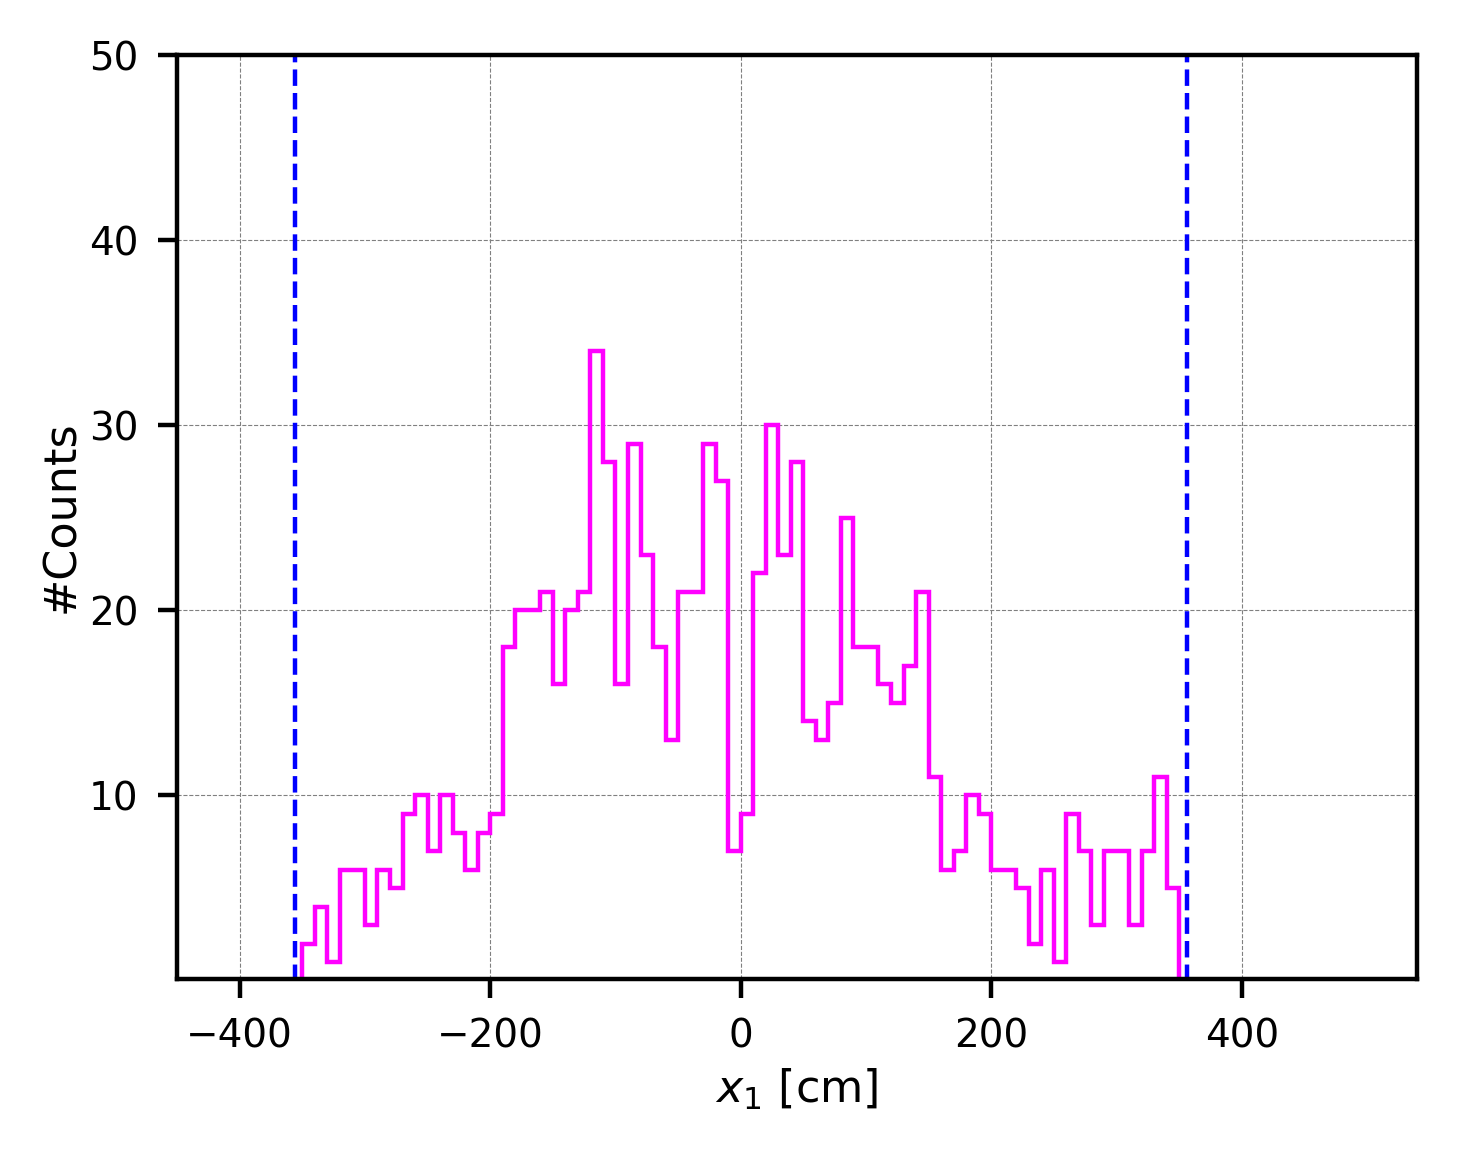

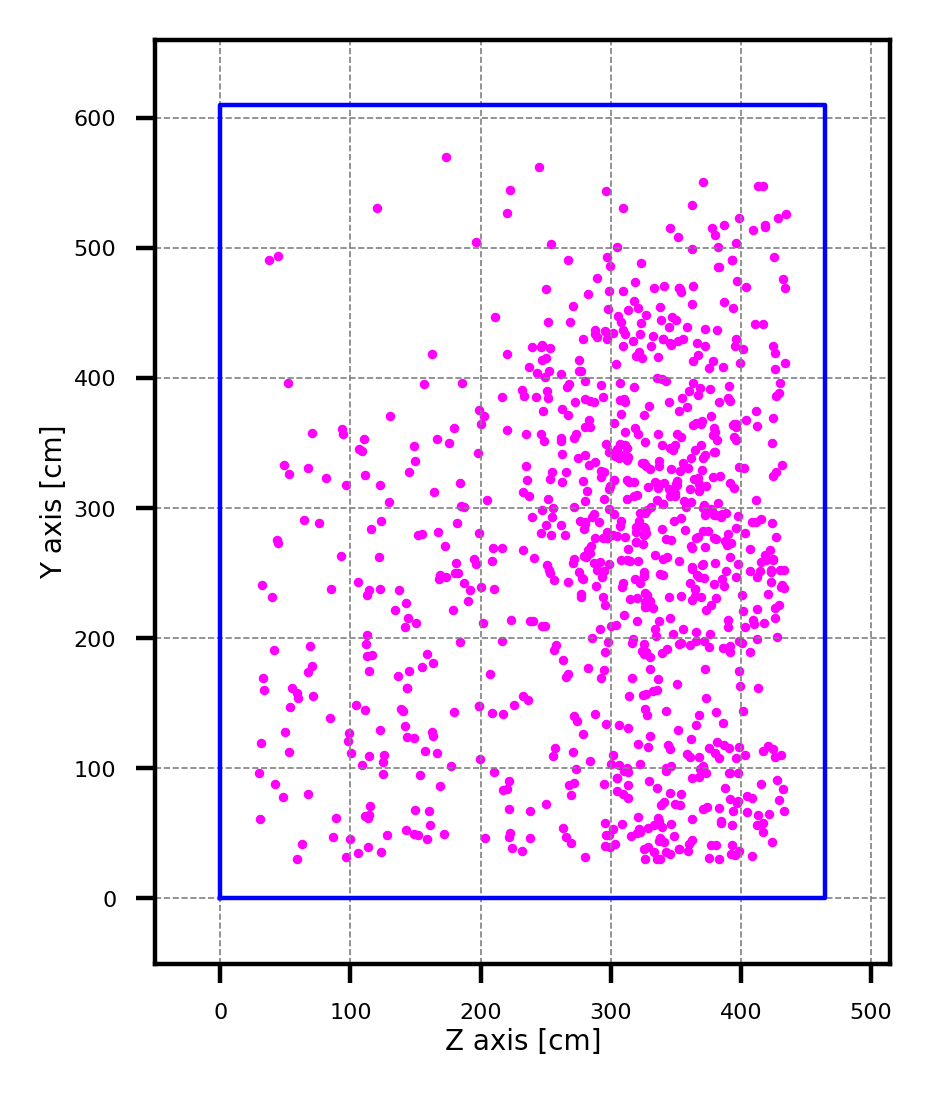

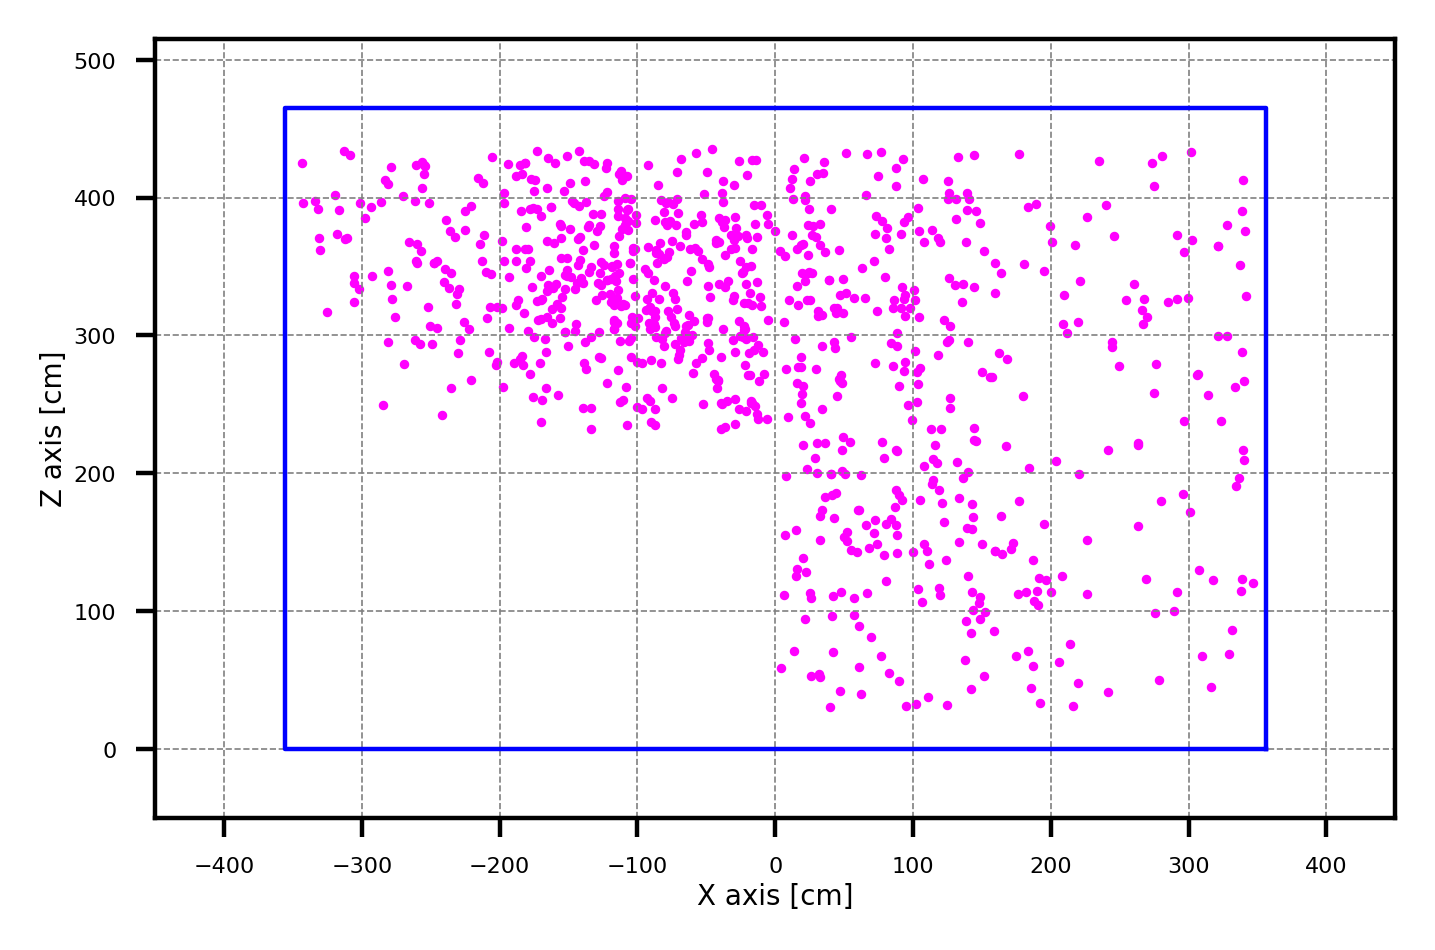

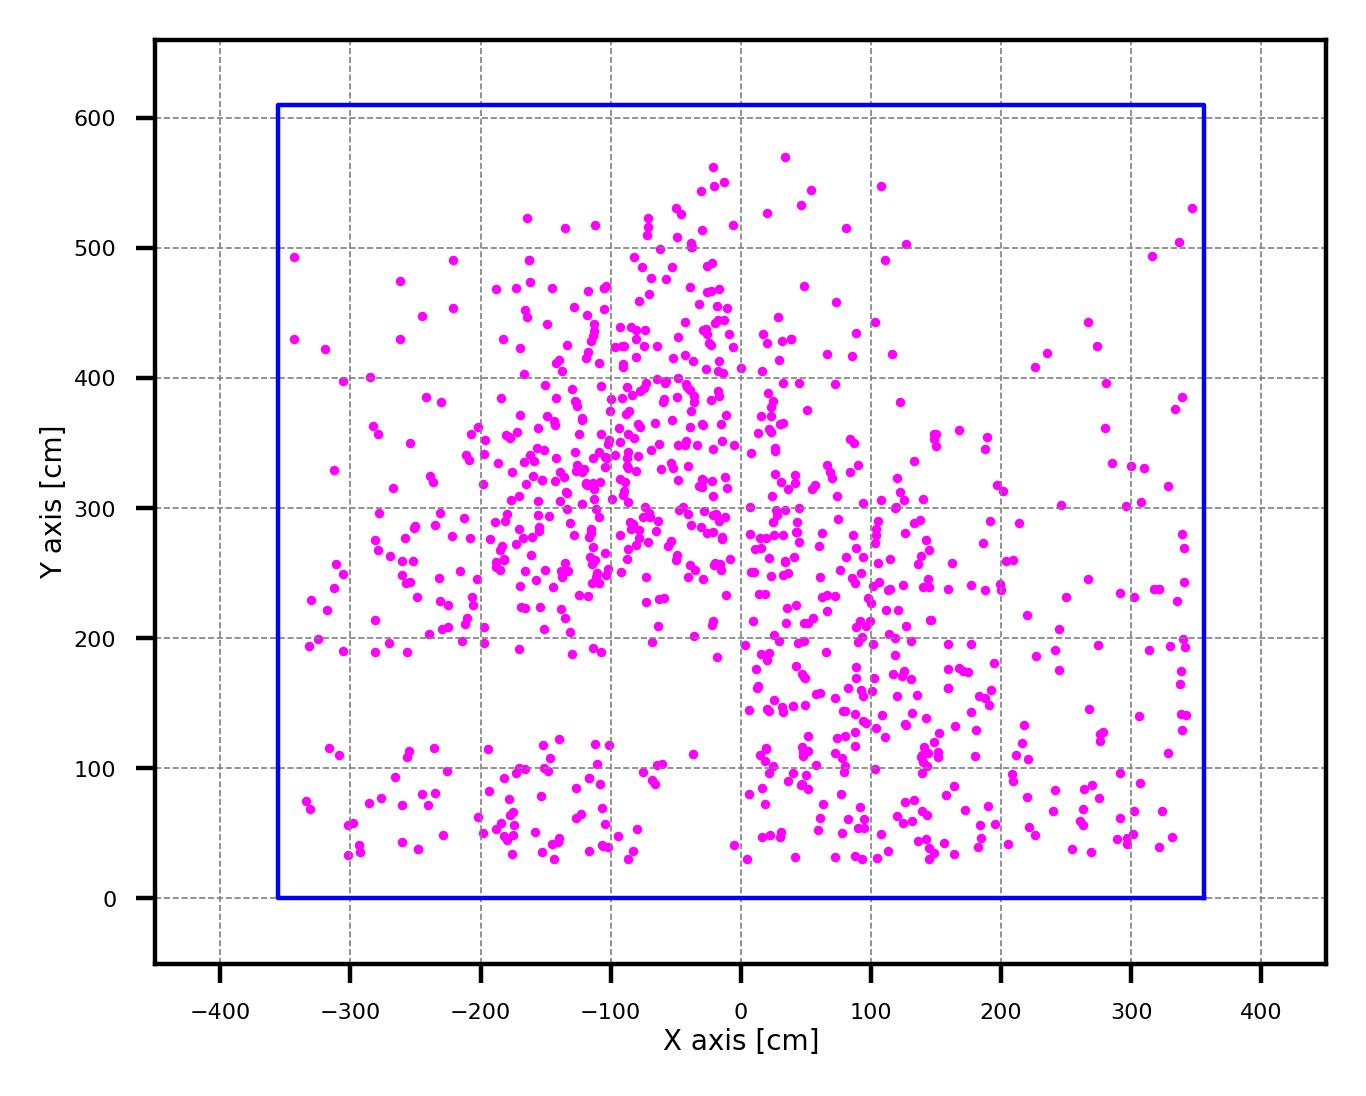

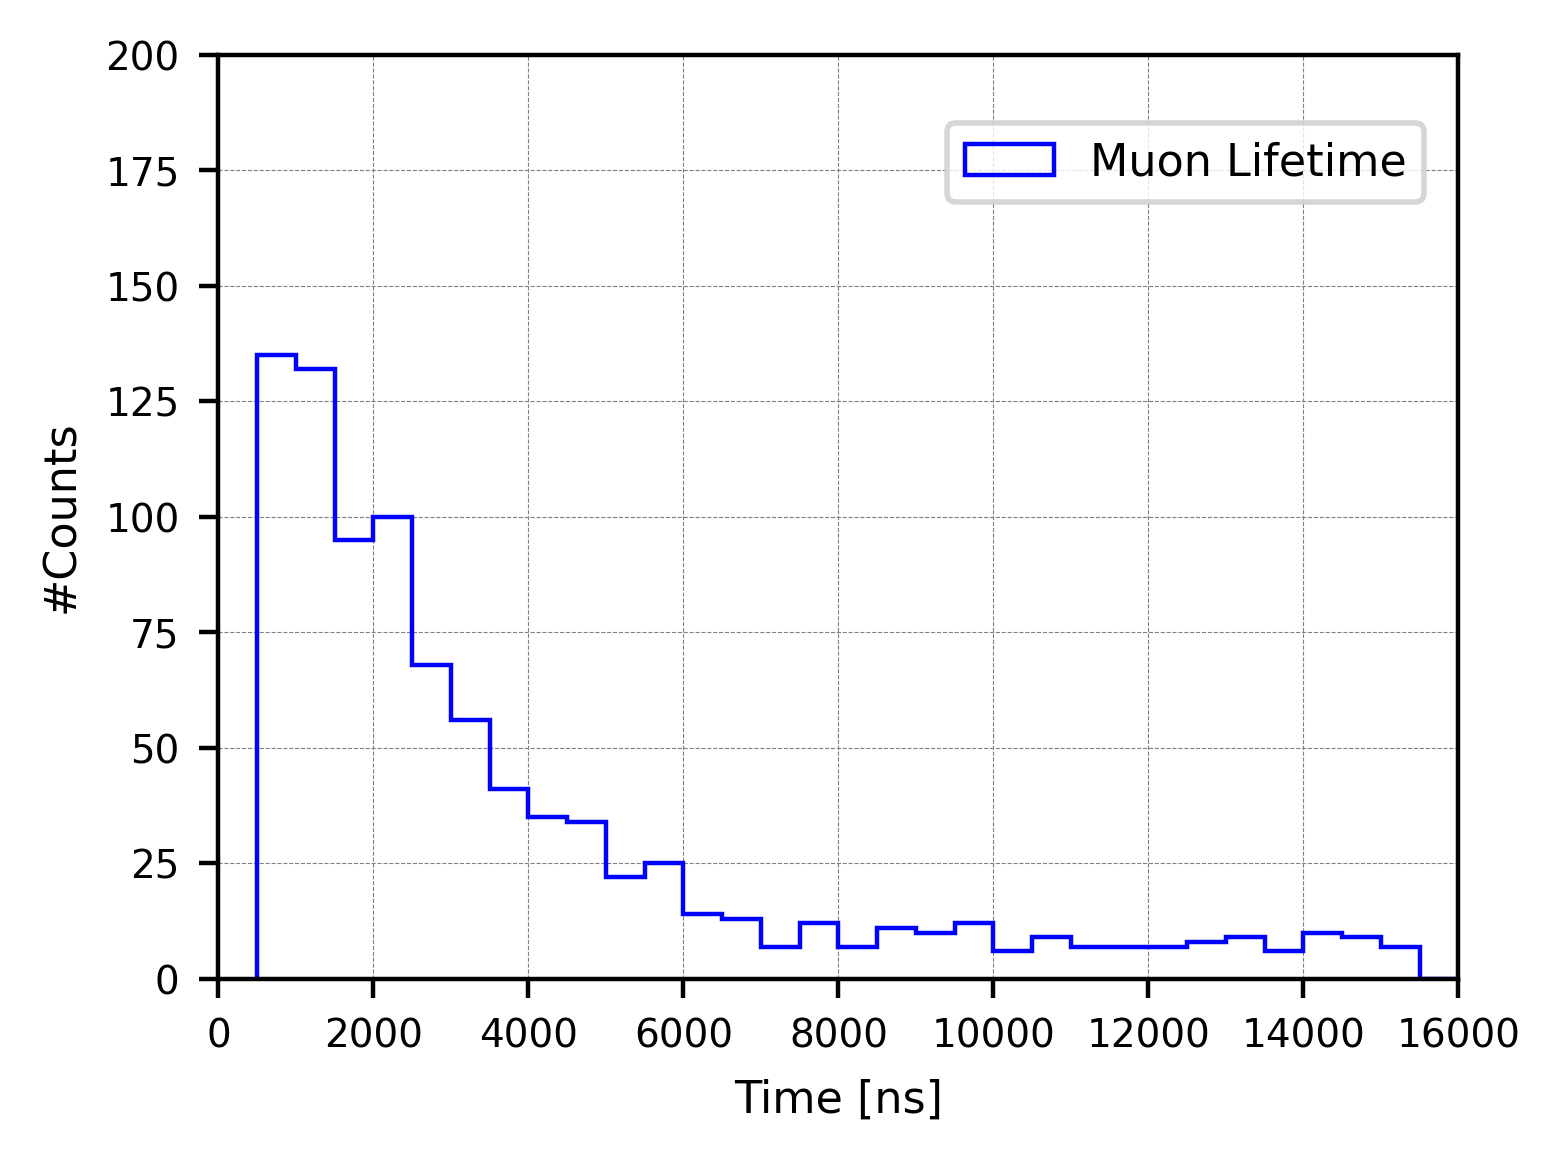


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 135 ± 11.6
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 132 ± 11.5
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 95 ± 9.7
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 100 ± 10.0
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 68 ± 8.2
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 56 ± 7.5
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 41 ± 6.4
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 35 ± 5.9
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 34 ± 5.8
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 22 ± 4.7
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 25 ± 5.0
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 14 ± 3.7
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 13 ± 3.6
Bin 14: Range = [7000, 7500) | Center = 7250 ns |

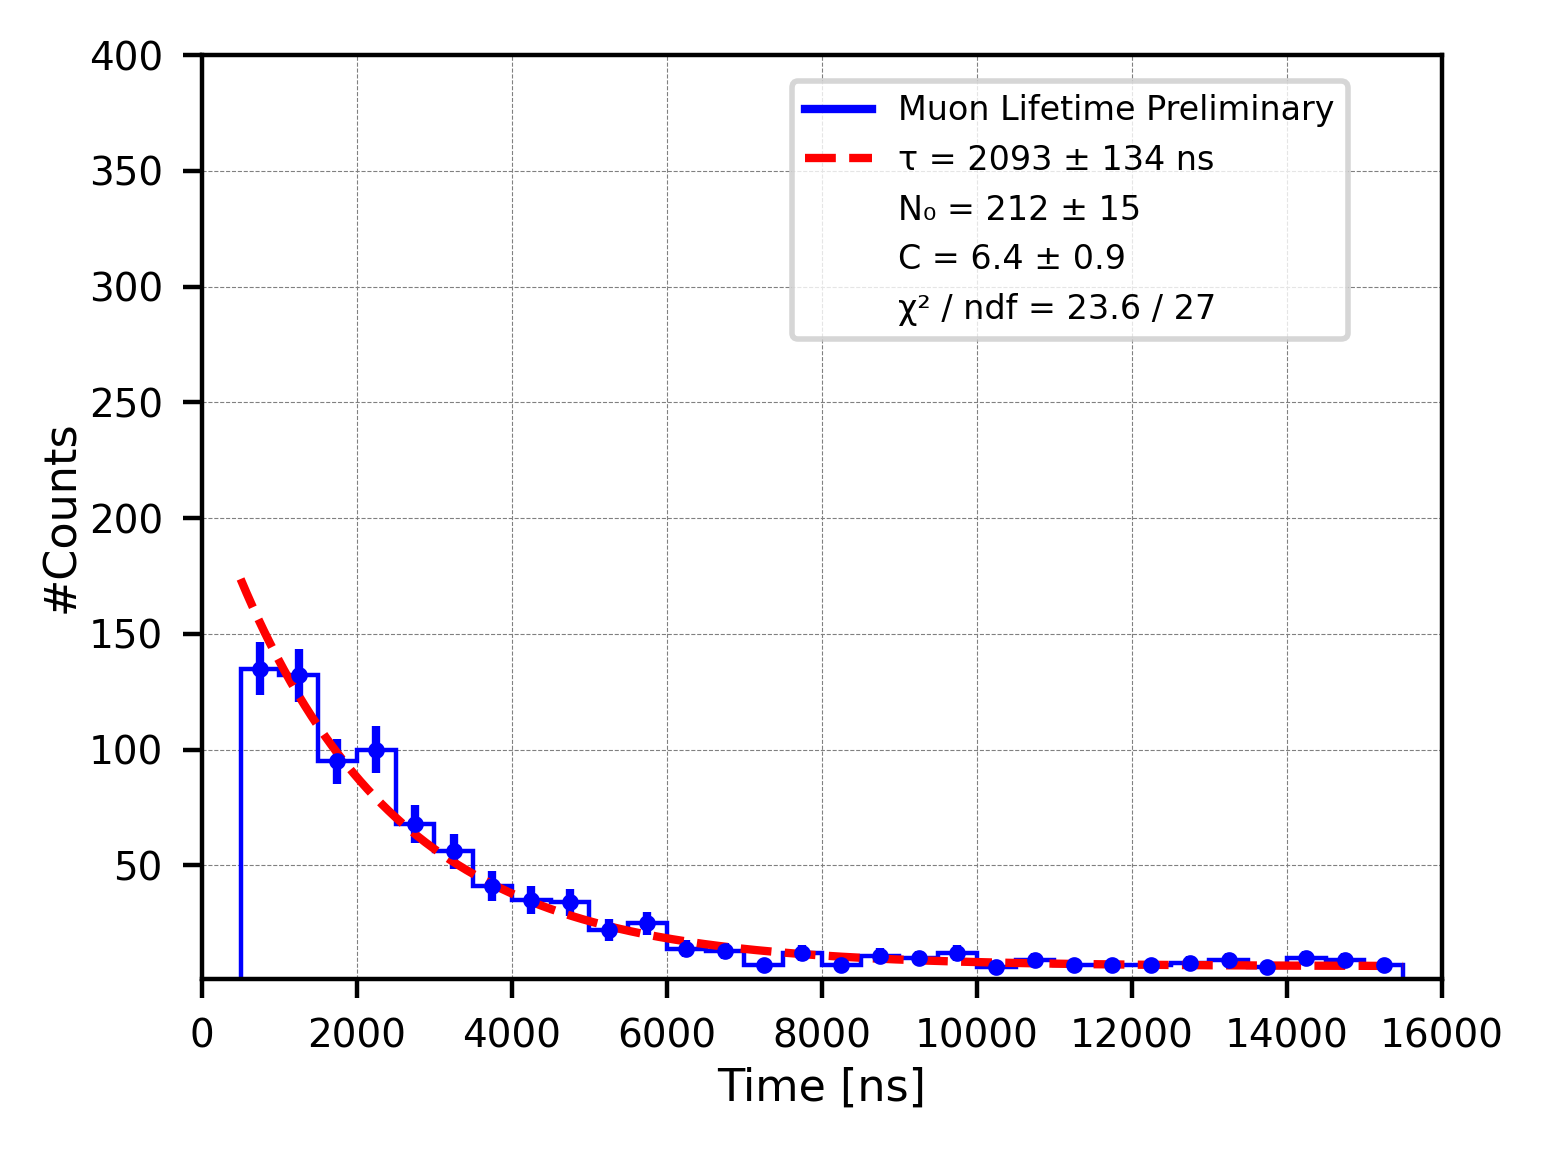

In [ ]:
# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)
#APA planes---
plt.plot([-356, -356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([356, 356], [0, 2000], color="blue", linewidth=0.8, linestyle='--')
#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(decayX_update_2, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-450, 540)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 50)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()  




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayZ_update_2, decayY_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()  





#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayX_update_2, decayZ_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 515)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 





#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)
#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(decayX_update_2, decayY_update_2, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 












# Muon Lifetime distribution (NO fitting)--------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Plot histogram-----------------
plt.hist(mu_lifetime_ns_update_2, bins=bins, range=(range_min, range_max),
         edgecolor='blue', histtype='step', linewidth=0.8,
         label='Muon Lifetime')

plt.xlim(0, 16000)
plt.ylim(0, 200)
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.78, 0.95), fontsize=11, markerscale=5, ncol=1, prop={'size':8})
plt.show()







#Fitting---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_update_2, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)

# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()





<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## Add fake data (test detection efficiency):


Least Square Fitting:==================

Bin information:
Bin 1: Range = [500, 1000) | Center = 750 ns | Entries = 185 ± 13.6
Bin 2: Range = [1000, 1500) | Center = 1250 ns | Entries = 132 ± 11.5
Bin 3: Range = [1500, 2000) | Center = 1750 ns | Entries = 95 ± 9.7
Bin 4: Range = [2000, 2500) | Center = 2250 ns | Entries = 100 ± 10.0
Bin 5: Range = [2500, 3000) | Center = 2750 ns | Entries = 68 ± 8.2
Bin 6: Range = [3000, 3500) | Center = 3250 ns | Entries = 56 ± 7.5
Bin 7: Range = [3500, 4000) | Center = 3750 ns | Entries = 41 ± 6.4
Bin 8: Range = [4000, 4500) | Center = 4250 ns | Entries = 35 ± 5.9
Bin 9: Range = [4500, 5000) | Center = 4750 ns | Entries = 34 ± 5.8
Bin 10: Range = [5000, 5500) | Center = 5250 ns | Entries = 22 ± 4.7
Bin 11: Range = [5500, 6000) | Center = 5750 ns | Entries = 25 ± 5.0
Bin 12: Range = [6000, 6500) | Center = 6250 ns | Entries = 14 ± 3.7
Bin 13: Range = [6500, 7000) | Center = 6750 ns | Entries = 13 ± 3.6
Bin 14: Range = [7000, 7500) | Center = 7250 ns |

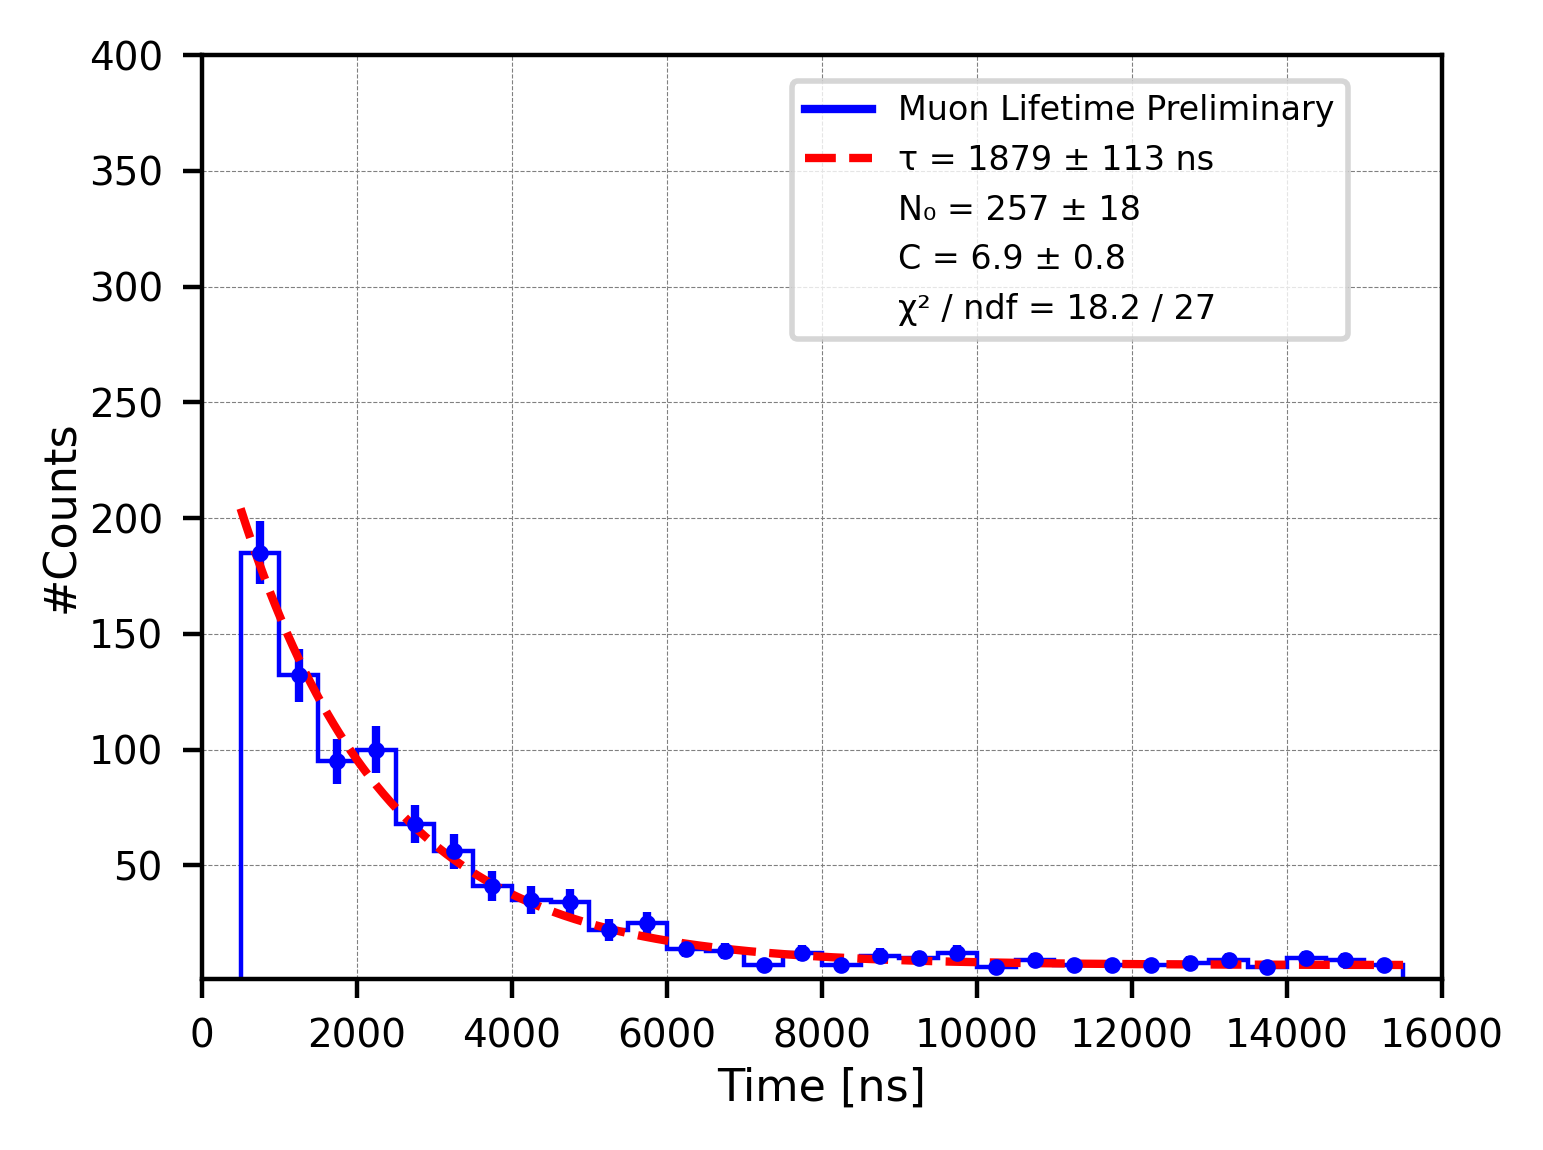

In [13]:


#Fake list: add some instances of "750"
mu_lifetime_ns_purified_500_fake = mu_lifetime_ns_purified_500 + [750] * 50




#Fitting---------------------------------------------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

print("\nLeast Square Fitting:==================")

# Define histogram parameters
bin_width = 500
range_min = 500
range_max = 15500
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Create the histogram and capture counts, bin edges, etc.
n, bin_edges, patches = plt.hist(mu_lifetime_ns_purified_500_fake, bins=bins, range=(range_min, range_max),
                                 edgecolor='blue', histtype='step', linewidth=0.8,
                                 label='Muon Lifetime Preliminary')

# Calculate bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Calculate statistical uncertainties (sqrt(n))
yerr = np.sqrt(n)
yerr_plot = np.where(n == 0, 1, yerr)  # Avoid zero division error for empty bins

# Plot error bars on the histogram
plt.errorbar(bin_centers, n, yerr=yerr, fmt='o', color='blue', markersize=2)


# Define the exponential fitting function: N(t) = N0 * exp(-t/tau0) + C
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Least Squares Method------
popt, pcov = curve_fit(exp_func, bin_centers, n, p0=[max(n), 1000, 1], sigma=yerr, absolute_sigma=True)
perr = np.sqrt(np.diag(pcov))  # parameter uncertainties

# Print entries and uncertainties for each bin
print("\nBin information:")
for i in range(len(n)):
    print(f"Bin {i+1}: Range = [{bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}) | "
          f"Center = {bin_centers[i]:.0f} ns | "
          f"Entries = {n[i]:.0f} ± {yerr[i]:.1f}")

# Print results to terminal
print("\nFitted parameters:")
print("N0 = {:.2f} +/- {:.2f}".format(popt[0], perr[0]))
print("tau0 = {:.2f} +/- {:.2f} ns".format(popt[1], perr[1]))
print("C = {:.2f} +/- {:.2f}".format(popt[2], perr[2]))

# Calculate chi-squared
expected = exp_func(bin_centers, *popt)
expected = np.clip(expected, 1e-10, None)  # Avoid division by zero
residuals = n - expected
chi2 = np.sum((residuals / yerr_plot) ** 2)
ndf = len(n) - len(popt)
chi2_ndf = chi2 / ndf

# Print goodness-of-fit summary
print(f"\n[Goodness of Fit] χ² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print detailed bin-by-bin information
for i, (label, observed, exp_val, res, err) in enumerate(zip(bin_centers, n, expected, residuals, yerr_plot)):
    print(f"Bin {i} (center={label:.2f}): n = {observed:.2f}; expected = {exp_val:.2f}; "
          f"residual = {res:.2f}; residual / yerr = {res / err:.2f}")

# Plot and legend----------
n0_text = f'N₀ = {popt[0]:.0f} ± {perr[0]:.0f}'
tau_text = f'τ = {popt[1]:.0f} ± {perr[1]:.0f} ns'
c_text = f'C = {popt[2]:.1f} ± {perr[2]:.1f}'
chi2_text = f'χ² / ndf = {chi2:.1f} / {ndf}'

t_fit = np.linspace(range_min, range_max, 1000)
fit_line, = plt.plot(t_fit, exp_func(t_fit, *popt), color='red', linestyle='--', label=tau_text)

# Dummy handles for text-only legend entries
dummy_n0 = plt.Line2D([], [], color='none', label=n0_text)
dummy_c = plt.Line2D([], [], color='none', label=c_text)
dummy_chi2 = plt.Line2D([], [], color='none', label=chi2_text)

# Histogram handle
hist_handle = plt.Line2D([], [], color='blue', linestyle='-', label='Muon Lifetime Preliminary')

plt.legend(handles=[hist_handle, fit_line, dummy_n0, dummy_c, dummy_chi2],
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=7, ncol=1, prop={'size': 6})

plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.show()
